# Ngày 1 — EDA & Tiền xử lý: Dự đoán Nghỉ việc Nhân sự

Notebook này thực hiện đúng các task của **Ngày 1** trong lộ trình 4 ngày:
khám phá dữ liệu (EDA), hiểu mức độ mất cân bằng, và tiền xử lý ban đầu.

> Chạy notebook này từ trong thư mục `notebooks/` (đường dẫn tương đối dùng `../data`, `../images`).

**Dataset:** IBM HR Analytics Employee Attrition & Performance
🔗 https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

PALETTE = {'Yes': '#e07a5f', 'No': '#3d5a80'}
pd.set_option('display.max_columns', 50)


## 1. Đọc & quan sát dữ liệu lần đầu

In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print("Kích thước dataset:", df.shape)


Kích thước dataset: (1470, 35)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 2. Kiểm tra biến mục tiêu `Attrition` — mức độ mất cân bằng

Đây là bước quan trọng nhất trước khi làm bất cứ điều gì khác: nếu tỷ lệ hai lớp quá lệch,
`Accuracy` sẽ đánh lừa chúng ta ở các bước sau (xem lại hộp "📘 Khái niệm" trong file lộ trình).

In [6]:
counts = df['Attrition'].value_counts()
pct = df['Attrition'].value_counts(normalize=True) * 100

summary = pd.DataFrame({'Số lượng': counts, 'Tỷ lệ (%)': pct.round(2)})
print(summary)
print(f"\n>>> Tỷ lệ mất cân bằng xấp xỉ 1 : {counts['No']/counts['Yes']:.1f}")


           Số lượng  Tỷ lệ (%)
Attrition                     
No             1233      83.88
Yes             237      16.12

>>> Tỷ lệ mất cân bằng xấp xỉ 1 : 5.2


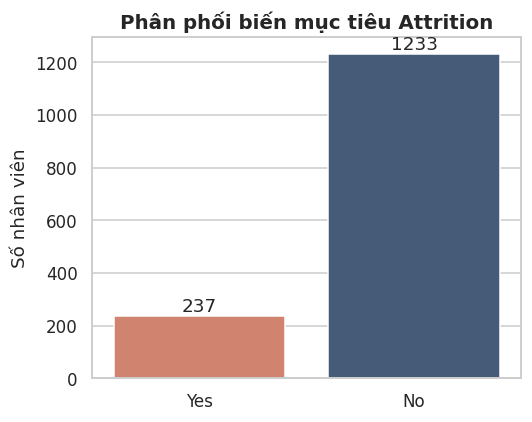

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Attrition', hue='Attrition', palette=PALETTE, legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title("Phân phối biến mục tiêu Attrition")
ax.set_xlabel("")
ax.set_ylabel("Số nhân viên")
plt.tight_layout()
plt.savefig("../images/01_attrition_distribution.png", bbox_inches='tight')
plt.show()


## 3. Phân phối các biến quan trọng theo Attrition

Xem 6 biến được nhắc tới nhiều trong tài liệu tham khảo của bài toán này:
`OverTime`, `MonthlyIncome`, `JobSatisfaction`, `YearsAtCompany`, `Age`, `DistanceFromHome`.

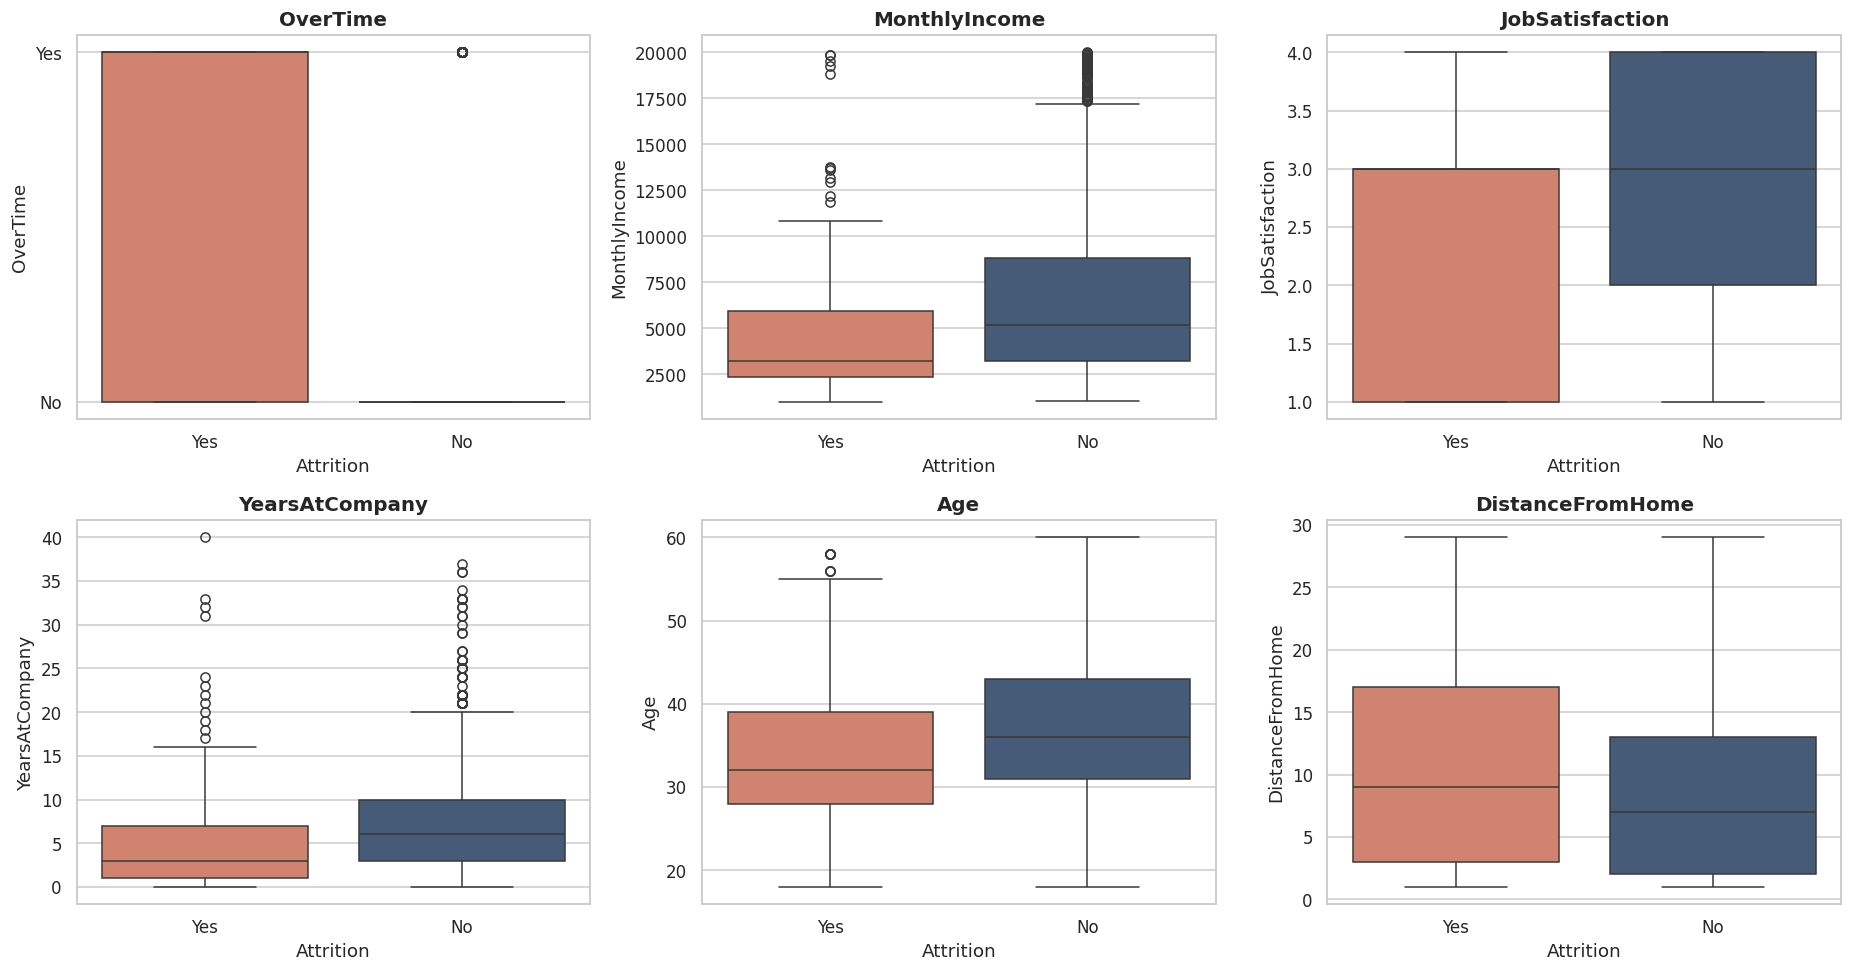

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
cols = ['OverTime', 'MonthlyIncome', 'JobSatisfaction',
        'YearsAtCompany', 'Age', 'DistanceFromHome']

for ax, col in zip(axes.flat, cols):
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col, hue='Attrition', palette=PALETTE, ax=ax)
    else:
        sns.boxplot(data=df, x='Attrition', y=col, hue='Attrition',
                     palette=PALETTE, legend=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.savefig("../images/02_eda_overview.png", bbox_inches='tight')
plt.show()


**Quan sát nhanh (điền/chỉnh lại theo đúng biểu đồ của bạn):**
- `OverTime = Yes` → tỷ lệ nghỉ việc cao hơn hẳn so với `OverTime = No`.
- `MonthlyIncome` của nhóm nghỉ việc có xu hướng thấp hơn nhóm ở lại.
- `JobSatisfaction` thấp (1-2) xuất hiện nhiều hơn ở nhóm nghỉ việc.
- Nhân viên trẻ tuổi (`Age` thấp) và mới vào công ty (`YearsAtCompany` thấp) có xu hướng nghỉ việc nhiều hơn.


## 4. Ma trận tương quan giữa các biến số

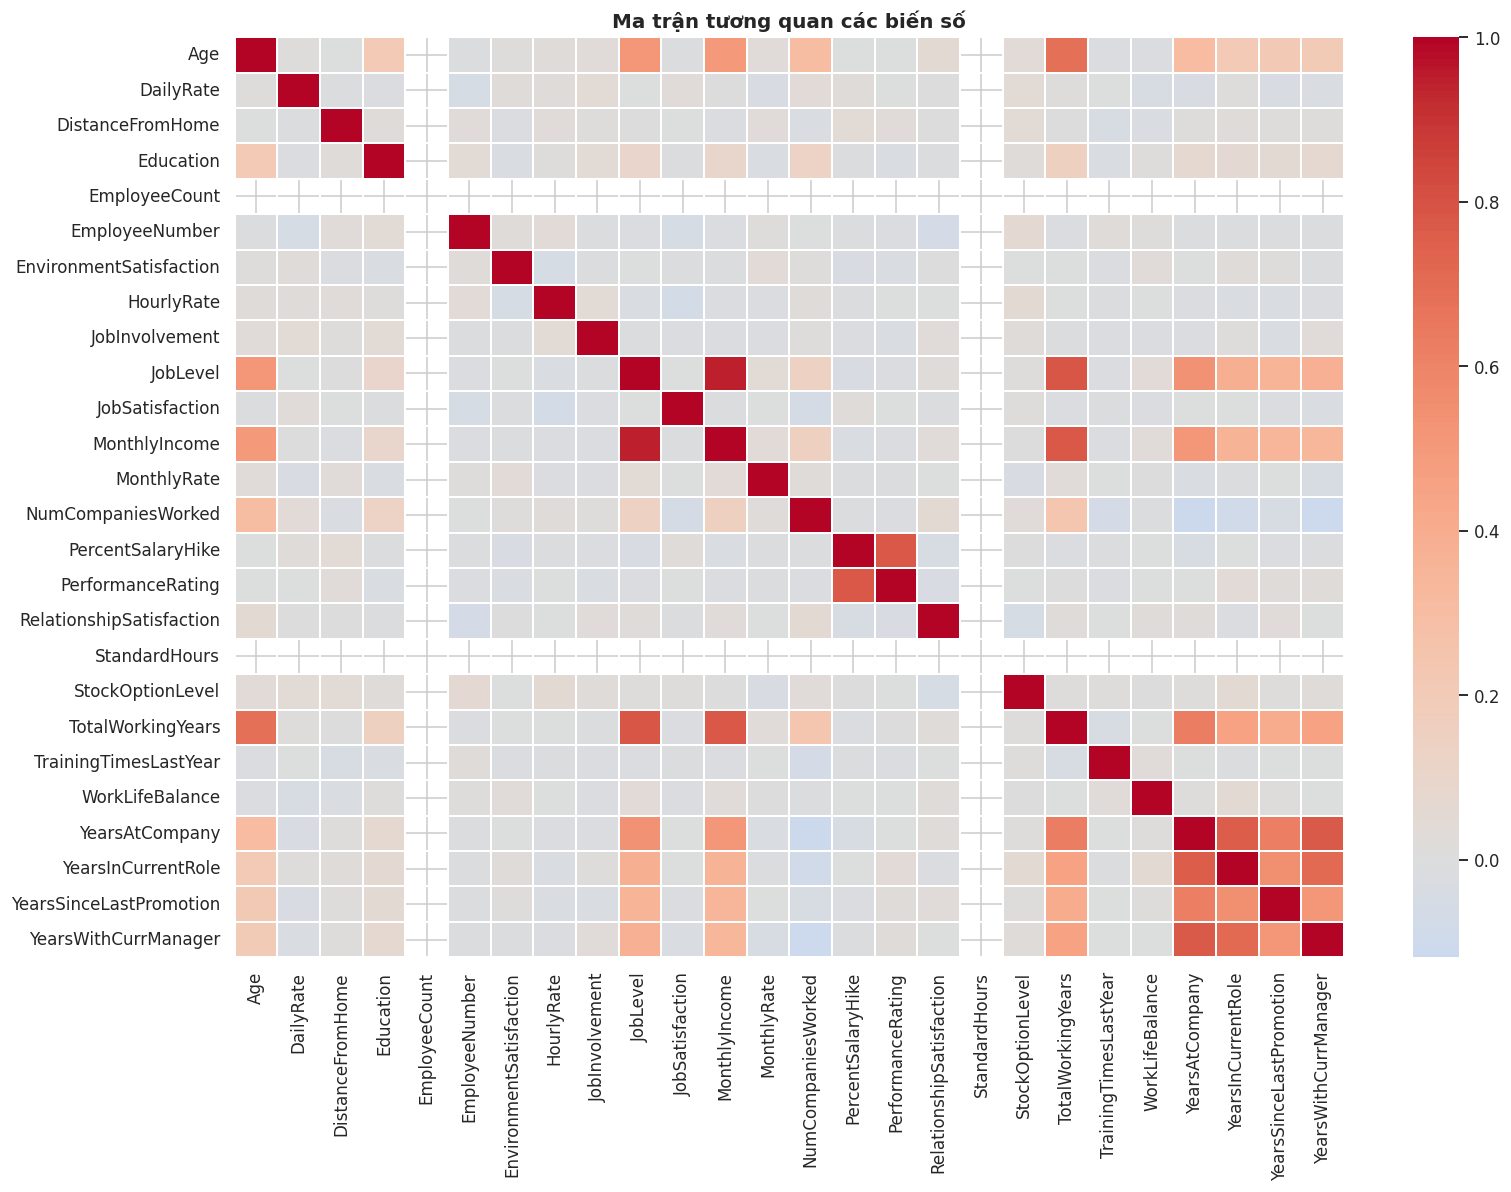

In [9]:
plt.figure(figsize=(15, 11))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title("Ma trận tương quan các biến số")
plt.tight_layout()
plt.savefig("../images/03_correlation_heatmap.png", bbox_inches='tight')
plt.show()


In [10]:
# Top 10 biến số tương quan mạnh nhất (dương hoặc âm) với việc nghỉ việc
df_temp = df.copy()
df_temp['Attrition_num'] = df_temp['Attrition'].map({'Yes': 1, 'No': 0})
corr_with_target = (df_temp.select_dtypes(include='number')
                     .corr()['Attrition_num']
                     .drop('Attrition_num')
                     .sort_values(key=abs, ascending=False))
print("Top 10 biến số tương quan (trị tuyệt đối) với Attrition:")
print(corr_with_target.head(10))


Top 10 biến số tương quan (trị tuyệt đối) với Attrition:
TotalWorkingYears      -0.171063
JobLevel               -0.169105
YearsInCurrentRole     -0.160545
MonthlyIncome          -0.159840
Age                    -0.159205
YearsWithCurrManager   -0.156199
StockOptionLevel       -0.137145
YearsAtCompany         -0.134392
JobInvolvement         -0.130016
JobSatisfaction        -0.103481
Name: Attrition_num, dtype: float64


## 5. Loại bỏ các cột vô nghĩa

Các cột dưới đây chỉ có **1 giá trị duy nhất** trên toàn bộ dataset, hoặc là ID không
mang thông tin dự đoán → không giúp ích gì cho mô hình.

In [11]:
check_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
print("Số giá trị duy nhất mỗi cột (trước khi loại bỏ):")
print(df[check_cols].nunique())

useless_cols = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']
df = df.drop(columns=useless_cols)
print(f"\nKích thước sau khi loại cột vô nghĩa: {df.shape}")


Số giá trị duy nhất mỗi cột (trước khi loại bỏ):
EmployeeCount        1
StandardHours        1
Over18               1
EmployeeNumber    1470
dtype: int64

Kích thước sau khi loại cột vô nghĩa: (1470, 31)


## 6. Mã hoá biến phân loại — One-Hot Encoding

`drop_first=True` để tránh đa cộng tuyến (bỏ bớt 1 cột dư thừa trong mỗi nhóm).
Biến mục tiêu `Attrition` được mã hoá riêng thành 0/1 (không one-hot).

In [12]:
categorical_cols = df.select_dtypes(include='object').columns.drop('Attrition')
print("Các cột phân loại sẽ được One-Hot Encode:", list(categorical_cols))

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded['Attrition'] = df_encoded['Attrition'].map({'Yes': 1, 'No': 0})

print(f"\nKích thước trước encode: {df.shape} -> sau encode: {df_encoded.shape}")
df_encoded.head()


Các cột phân loại sẽ được One-Hot Encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Kích thước trước encode: (1470, 31) -> sau encode: (1470, 45)


/tmp/ipykernel_534/616117851.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.drop('Attrition')


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


> ⚠️ **Lưu ý:** chưa chuẩn hoá (StandardScaler) các cột số ở bước này — việc đó để dành
> cho **đầu Ngày 2**, sau khi chia train/test, nhằm tránh rò rỉ dữ liệu (data leakage).
> Xem lại hộp "📘 Khái niệm: Rò rỉ dữ liệu" trong file lộ trình.

## 7. Lưu dữ liệu đã xử lý

In [13]:
df_encoded.to_csv("../data/processed/attrition_encoded.csv", index=False)
print("Đã lưu:", "data/processed/attrition_encoded.csv")
print("Kích thước cuối cùng:", df_encoded.shape)


Đã lưu: data/processed/attrition_encoded.csv
Kích thước cuối cùng: (1470, 45)


## Tổng kết Ngày 1

- ✅ Đã tải và hiểu cấu trúc dataset (1.470 dòng × 35 cột gốc)
- ✅ Định lượng được tỷ lệ mất cân bằng của `Attrition`
- ✅ Có 3 nhóm biểu đồ EDA + quan sát bằng lời
- ✅ Loại 4 cột vô nghĩa, One-Hot Encode xong các biến phân loại
- ✅ File `attrition_encoded.csv` đã lưu vào `data/processed/`

**Bước tiếp theo (Ngày 2):** Stratified Train/Test Split → StandardScaler (chỉ fit trên train)
→ SMOTE (chỉ trên train) → mô hình baseline Logistic Regression.
